In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/document_data_clean_filtered.csv")

# 0) Specifications

In [3]:
palette_types = {
    'annuaire': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
    'presse généraliste': 'tab:orange',
    'presse spécialisée': 'tab:green',
    'presse officielle': 'tab:red',
    'monographie': 'tab:blue',
}

# 1) Person and Institutions

In [4]:
df["author_type_clean"].value_counts()

author_type_clean
entity    6734
person    3923
Name: count, dtype: int64

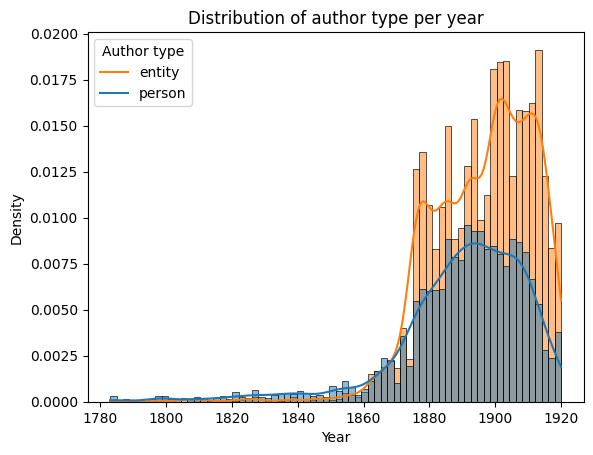

In [5]:
sns.histplot(df, x="date_clean", bins=70, hue="author_type_clean", kde=True, stat="density", label="Eucalyptus", alpha=0.5)
plt.title("Distribution of author type per year")
plt.xlabel("Year")
plt.legend(title='Author type', loc='upper left', labels=['entity', 'person'])

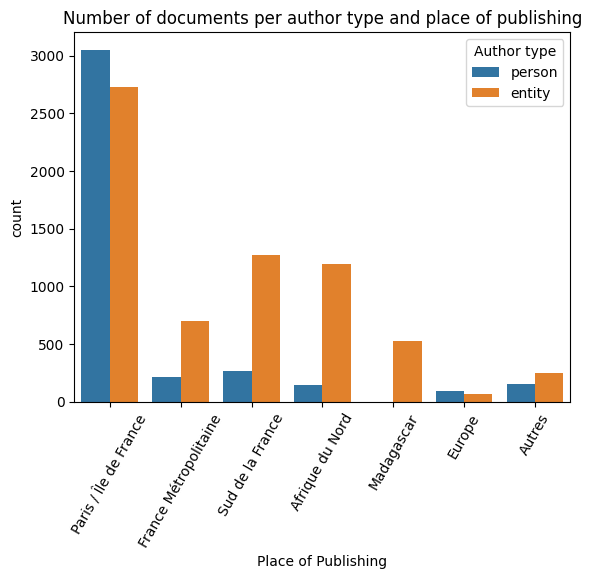

In [6]:
row_order = ["Paris / Île de France", "France Métropolitaine", "Sud de la France", "Afrique du Nord", "Madagascar", "Europe", "Autres"]
sns.countplot(data=df, x="publisher_place_country", hue="author_type_clean", order=row_order)
plt.xticks(rotation=60)
plt.title("Number of documents per author type and place of publishing")
plt.xlabel("Place of Publishing")
plt.legend(title='Author type', loc='upper right', labels=['person', 'entity'])
plt.show()

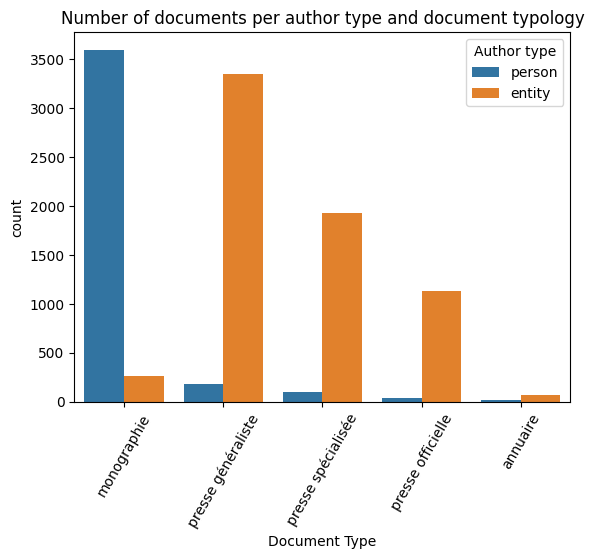

In [7]:
sns.countplot(data=df, x="type_clean", hue="author_type_clean")
plt.xticks(rotation=60)
plt.title("Number of documents per author type and document typology")
plt.xlabel("Document Type")
plt.legend(title='Author type', loc='upper right', labels=['person', 'entity'])
plt.show()

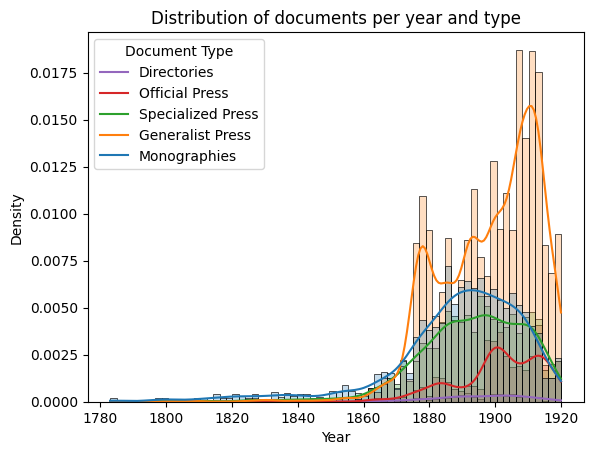

In [8]:
sns.histplot(df, x="date_clean", hue="type_clean", kde=True, bins=70, stat="density", label='Documents', palette=palette_types, alpha=0.25)
plt.title("Distribution of documents per year and type")
plt.xlabel("Year")
plt.legend(title='Document Type', loc='upper left', labels=['Directories', "Official Press", "Specialized Press", "Generalist Press", "Monographies"])
plt.show()

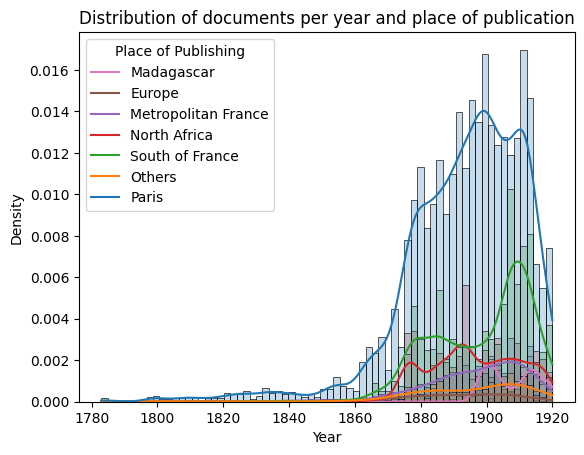

In [9]:
sns.histplot(df, x="date_clean", hue="publisher_place_country", kde=True, bins=70, stat="density", label='Documents', alpha=0.25)
plt.title("Distribution of documents per year and place of publication")
plt.xlabel("Year")
plt.legend(title='Place of Publishing', loc='upper left', labels=['Madagascar', "Europe", "Metropolitan France", "North Africa", "South of France", "Others", "Paris"])
plt.show()

## 1.1) Madagascar

In [10]:
df_officielle = df[df["type_clean"] == "presse officielle"]
df_officielle[df_officielle["date_clean"] > 1897]["publisher_place_country"].value_counts(normalize=True)

publisher_place_country
Madagascar               0.491870
Paris / Île de France    0.258130
Autres                   0.089431
Afrique du Nord          0.088415
Sud de la France         0.050813
France Métropolitaine    0.020325
Europe                   0.001016
Name: proportion, dtype: float64

In [11]:
df_madagascar = df[df["publisher_place_country"] == "Madagascar"]
df_madagascar["title_clean"].value_counts(normalize=True)

title_clean
Journal officiel de Madagascar et dépendances                                                  0.866038
Bulletin économique                                                                            0.041509
Journal officiel de Madagascar et dépendances. Supplément commercial (Tamatave et Côte Est)    0.028302
Feuille de renseignements économiques. Tamatave et Côte Est                                    0.013208
Revue agricole et vétérinaire de Madagascar et dépendances                                     0.011321
Guide-annuaire de Madagascar et dépendances                                                    0.011321
Notes, reconnaissances et explorations                                                         0.009434
L'Agriculture et l'élevage à Madagascar                                                        0.009434
Annuaire général de Madagascar et dépendances                                                  0.007547
De Marseille à Tananarive (avril-juin 1917)         

In [12]:
df_madagascar["date_clean"].sort_values()

3241    1897.0
3328    1897.0
3352    1897.0
3368    1897.0
3369    1897.0
         ...  
9740    1920.0
9745    1920.0
9747    1920.0
9751    1920.0
9756    1920.0
Name: date_clean, Length: 530, dtype: float64

In [13]:
df[df["date_clean"] >= 1897]["occurences_ratio"].describe()

count    9112.000000
mean        0.009130
std         0.034975
min         0.000064
25%         0.002177
50%         0.004346
75%         0.009522
max         2.762240
Name: occurences_ratio, dtype: float64

In [14]:
df_madagascar[df_madagascar["date_clean"] >= 1897]["occurences_ratio"].describe()

count    530.000000
mean       0.010052
std        0.023153
min        0.000341
25%        0.003401
50%        0.005480
75%        0.009839
max        0.395163
Name: occurences_ratio, dtype: float64

## 1.2) Lyon

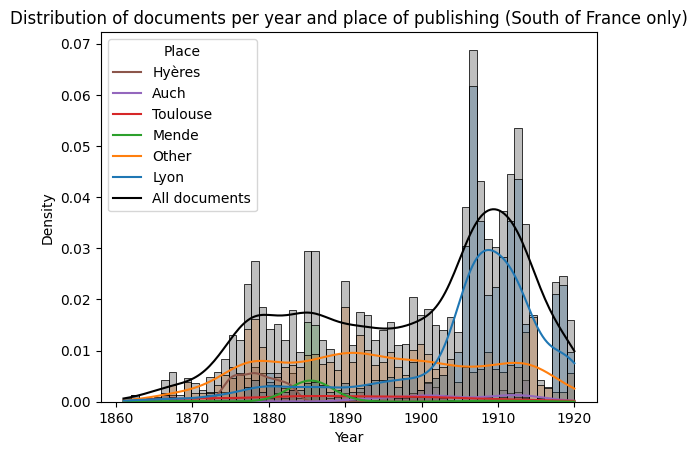

In [15]:
df_south = df[df["publisher_place_country"] == "Sud de la France"]
df_south = df_south[df_south["date_clean"] > 1860]
def place_test(place):
    if place in ["Lyon", "Mende", "Toulouse", "Hyères", "Auch"]:
        return place
    else:
        return "Other"
df_south["place_test"] = df_south["publisher_place_clean"].map(place_test)
bins = int(1920-1860)

sns.histplot(df_south, x="date_clean", hue="place_test", kde=True, bins=bins, stat="density", alpha=0.25)
sns.histplot(df_south, x="date_clean", kde=True, bins=bins, stat="density", color="black", alpha=0.25)

plt.title("Distribution of documents per year and place of publishing (South of France only)")
plt.xlabel("Year")
plt.legend(title='Place', loc='upper left', labels=["Hyères", "Auch", "Toulouse", "Mende", "Other", "Lyon", "All documents"])
plt.show()

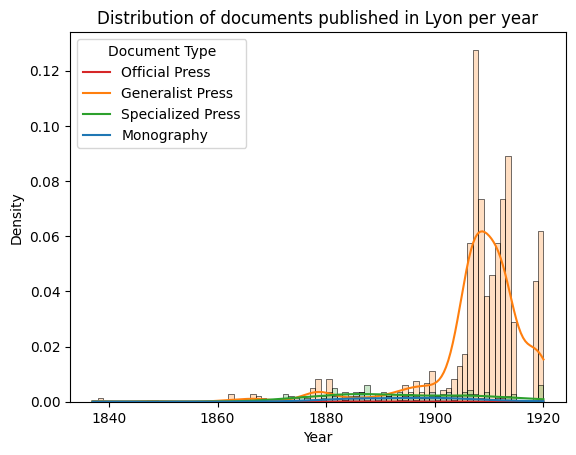

In [16]:
bins = int(df[df["publisher_place_clean"] == "Lyon"]["date_clean"].max() - df[df["publisher_place_clean"] == "Lyon"]["date_clean"].min())

sns.histplot(df[df["publisher_place_clean"] == "Lyon"], x="date_clean", hue="type_clean", kde=True, bins=bins, stat="density", palette=palette_types, alpha=0.25)
plt.title("Distribution of documents published in Lyon per year")
plt.legend(title='Document Type', loc='upper left', labels=["Official Press", "Generalist Press", "Specialized Press", "Monography"])
plt.xlabel("Year")
plt.show()

In [17]:
df_generaliste = df[df["type_clean"] == "presse généraliste"]
df_generaliste_no_lyon = df_generaliste[df_generaliste["publisher_place_clean"] != "Lyon"]
df_generaliste_no_lyon[df_generaliste_no_lyon["date_clean"] >= 1900]["occurences_ratio"].describe()

count    3247.000000
mean        0.009267
std         0.017940
min         0.000064
25%         0.002788
50%         0.005258
75%         0.010534
max         0.435256
Name: occurences_ratio, dtype: float64

In [18]:
df_lyon = df[df["publisher_place_clean"] == "Lyon"]
df_lyon[df_lyon["date_clean"] >= 1900]["occurences_ratio"].describe()

count    1173.000000
mean        0.004746
std         0.004175
min         0.000159
25%         0.002604
50%         0.003222
75%         0.005498
max         0.066434
Name: occurences_ratio, dtype: float64

In [19]:
df_lyon["title_clean"].value_counts()

title_clean
Le Progrès                                                           1187
Lyon médical                                                           68
Lyon horticole                                                         38
La Province médicale                                                   24
Annales de la propagation de la foi                                    10
                                                                     ... 
Questions pratiques de législation ouvrière et d'économie sociale       1
Atlas-géographie, ou Nouveau manuel de géographie générale              1
Revue musicale de Lyon                                                  1
Bulletin des catéchismes de St-Irénée, Lyon                             1
Le paludisme en Italie                                                  1
Name: count, Length: 94, dtype: int64

In [25]:
len(df_lyon)

1458

In [23]:
df_south_france = df[df["publisher_place_country"] == "Sud de la France"]
df_south_france[df_south_france["date_clean"] < 1900]["publisher_place_clean"].value_counts(normalize=True)

publisher_place_clean
Lyon           0.200704
Hyères         0.105634
Toulouse       0.073239
Mende          0.070423
Ajaccio        0.050000
                 ...   
Roanne         0.000704
La Réole       0.000704
Brioude        0.000704
Isère          0.000704
Saint-Flour    0.000704
Name: proportion, Length: 86, dtype: float64

In [24]:
df_south_france[df_south_france["date_clean"] >= 1900]["publisher_place_clean"].value_counts(normalize=True)

publisher_place_clean
Lyon           0.674914
Auch           0.038550
Perpignan      0.027043
Toulouse       0.021864
Apt            0.016110
                 ...   
Trévoux        0.000575
Voiron         0.000575
Lavaur         0.000575
Isère          0.000575
Beauchastel    0.000575
Name: proportion, Length: 72, dtype: float64